In [ ]:
# Imports

%matplotlib inline
import os
import json
import zipfile
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI

In [23]:
# Extract Dataset

# Path to zipped dataset
zip_path = "SBAnational.csv.zip"
extract_path = "./"
csv_path = os.path.join(extract_path, "SBAnational.csv")

# Only extract if file doesn't already exist
if not os.path.exists(csv_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted.")
else:
    print("Dataset already exists. Skipping extraction.")

Dataset already exists. Skipping extraction.


In [24]:
# Load Dataset

df = pd.read_csv("SBAnational.csv")
print(df.shape)
df.head()

C:\Users\elear\AppData\Local\Temp\ipykernel_27356\1581875280.py:3: DtypeWarning: Columns (0: ApprovalFY) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("SBAnational.csv")


(899164, 27)


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [25]:
# Load Environment Variables

# Load variables from .env file into environment
load_dotenv()

# Retrieve OpenAI API key
api_key = os.getenv("OPENAI_API_KEY")

# Validate API key exists
if not api_key:
    raise ValueError("OPENAI_API_KEY not found. Check your .env file.")

# Initialize OpenAI client with API key
client = OpenAI(api_key=api_key)

In [26]:
# Utility Functions

def safe_str(value):
    """
    Safely convert values to string.
    Replaces NaN or missing values with 'Unknown'.
    """
    if pd.isna(value):
        return "Unknown"
    return str(value)

In [27]:
# Build Loan Profile with LLM Input
def build_loan_profile(row):
    """
    Convert a dataframe row into a structured text description
    to be sent to the LLM for feature extraction.
    """

    return f"""
Small business loan profile:

Borrower name: {safe_str(row.get('Name'))}
City: {safe_str(row.get('City'))}
State: {safe_str(row.get('State'))}
ZIP code: {safe_str(row.get('Zip'))}

NAICS code: {safe_str(row.get('NAICS'))}
Loan term (months): {safe_str(row.get('Term'))}
Number of employees: {safe_str(row.get('NoEmp'))}

Business status (1=existing, 2=new): {safe_str(row.get('NewExist'))}
Urban/Rural code: {safe_str(row.get('UrbanRural'))}

Revolving line of credit: {safe_str(row.get('RevLineCr'))}
Low documentation loan: {safe_str(row.get('LowDoc'))}

Disbursement amount: {safe_str(row.get('DisbursementGross'))}
Gross approved amount: {safe_str(row.get('GrAppv'))}
SBA guaranteed amount: {safe_str(row.get('SBA_Appv'))}
""".strip()

In [ ]:
# Prompt Configuration

# System prompt defines the model's role, output format,
# and strict JSON-only response behavior.
SYSTEM_PROMPT = """
You are a financial data structuring assistant.

Your task is to convert semi-structured small-business loan records
into structured JSON for downstream analysis.

Return only valid JSON.
Do not include markdown.
Do not add commentary.
Do not include any keys other than those requested.
"""



# Extract Structured Features with OpenAI

def extract_structured_loan_features(loan_text):
    """
    Send a loan profile to the OpenAI model and return
    structured financial features as a Python dictionary.

    Expected JSON keys:
    - industry_label
    - business_stage
    - loan_backing_type
    - risk_factors
    - geo_context
    - risk_summary
    - risk_score
    """

    # User prompt defines the exact schema for structured extraction.
    # The risk_score is an LLM-derived quantitative feature representing
    # overall default risk on a 0-100 scale.
    user_prompt = f"""
Extract structured features from the loan profile below.

Return valid JSON with exactly these keys and no additional keys:
- industry_label: string
- business_stage: string
- loan_backing_type: string
- risk_factors: array of strings
- geo_context: string
- risk_summary: string
- risk_score: integer between 0 and 100

Scoring guidance for risk_score:
- 0 = very low default risk
- 25 = relatively low risk
- 50 = moderate risk
- 75 = high risk
- 100 = very high default risk

Base the risk_score on the combined financial and business context in the record,
including factors such as business maturity, documentation level, employee count,
loan structure, and geographic or industry-related signals when relevant.

Loan profile:
{loan_text}
"""

    # Send request to OpenAI model
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        temperature=0,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
    )

    # Extract raw text response from model
    content = response.choices[0].message.content

    # Parse JSON response into a Python dictionary
    try:
        return json.loads(content)
    except json.JSONDecodeError:
        raise ValueError(f"Model did not return valid JSON:\n{content}")

In [ ]:

# Sample LLM Extraction on Loan Records

sample_df = df.sample(3, random_state=42).copy()

for idx, row in sample_df.iterrows():
    try:
        # Convert row into LLM input format
        profile = build_loan_profile(row)

        # Extract structured features using LLM
        structured_output = extract_structured_loan_features(profile)

        # Print results for inspection
        print(f"Row index: {idx}")
        print(json.dumps(structured_output, indent=2))
        print("-" * 60)

    except Exception as e:
        # Catch and display errors clearly
        print(f"Failed on row {idx}: {e}")
        print("-" * 60)

Row index: 614156
{
  "industry_label": "Unknown",
  "business_stage": "new",
  "loan_backing_type": "SBA guaranteed",
  "risk_factors": [
    "new business",
    "very small employee count",
    "unknown industry",
    "urban location"
  ],
  "geo_context": "West Seneca, NY, ZIP 14224",
  "risk_summary": "The loan is for a new business with only 2 employees and no industry classification, which increases uncertainty. However, the loan is SBA guaranteed, reducing lender risk. The urban location may provide market opportunities but also competition.",
  "risk_score": 70
}
------------------------------------------------------------
Row index: 837937
{
  "industry_label": "Building Finishing Contractors",
  "business_stage": "existing",
  "loan_backing_type": "SBA guaranteed",
  "risk_factors": [
    "small employee count",
    "short loan term",
    "high loan amount relative to business size"
  ],
  "geo_context": "urban area in Atkinson, NH",
  "risk_summary": "Established small busin

In [ ]:

# Batch LLM Enrichment

# Run LLM-based feature extraction on a limited sample of rows
# and append the returned structured fields back to the dataframe.

def enrich_dataframe_with_llm(df, max_rows=50):
    """
    Enrich a subset of the dataframe with LLM-derived structured features.
    """
    enriched_rows = []

    # Limit processing to a manageable subset for cost and debugging
    working_df = df.head(max_rows).copy()

    for idx, row in working_df.iterrows():
        try:
            # Build text profile from row
            profile = build_loan_profile(row)

            # Extract structured features from OpenAI
            structured_output = extract_structured_loan_features(profile)

            # Start with original row data
            enriched_row = row.to_dict()

            # Append LLM-derived fields
            enriched_row["llm_industry_label"] = structured_output.get("industry_label")
            enriched_row["llm_business_stage"] = structured_output.get("business_stage")
            enriched_row["llm_loan_backing_type"] = structured_output.get("loan_backing_type")
            enriched_row["llm_risk_factors"] = ", ".join(structured_output.get("risk_factors", []))
            enriched_row["llm_geo_context"] = structured_output.get("geo_context")
            enriched_row["llm_risk_summary"] = structured_output.get("risk_summary")
            enriched_row["llm_risk_score"] = structured_output.get("risk_score")

            enriched_rows.append(enriched_row)

        except Exception as e:
            print(f"Failed on row {idx}: {e}")

    return pd.DataFrame(enriched_rows)

enriched_df = enrich_dataframe_with_llm(df, max_rows=50)
print(enriched_df.shape)
enriched_df.head()

In [ ]:
# Run and Save Output
enriched_df = enrich_dataframe_with_llm(df, max_rows=50)
print(enriched_df.shape)
enriched_df.head()

enriched_df.to_csv("llm_enriched_loans_sample.csv", index=False)

In [48]:
# Inspect LLM-Derived Fields
print(enriched_df[[
    "llm_industry_label",
    "llm_business_stage",
    "llm_loan_backing_type",
    "llm_risk_score"
]].head(10))

print(enriched_df["llm_risk_score"].describe())

                  llm_industry_label llm_business_stage llm_loan_backing_type  \
0        Hobby, Toy, and Game Stores                new        SBA guaranteed   
1           Full-Service Restaurants                new        SBA guaranteed   
2                Offices of Dentists           existing        SBA guaranteed   
3            Pawn and Jewelry Retail           existing        SBA guaranteed   
4                            Unknown           existing        SBA guaranteed   
5                      Machine Shops           existing        SBA guaranteed   
6                            Unknown                new        SBA guaranteed   
7  Automotive Repair and Maintenance                new        SBA guaranteed   
8             Traveler Accommodation                new        SBA guaranteed   
9                            Unknown                new        SBA guaranteed   

   llm_risk_score  
0              65  
1              60  
2              40  
3              50  
4       

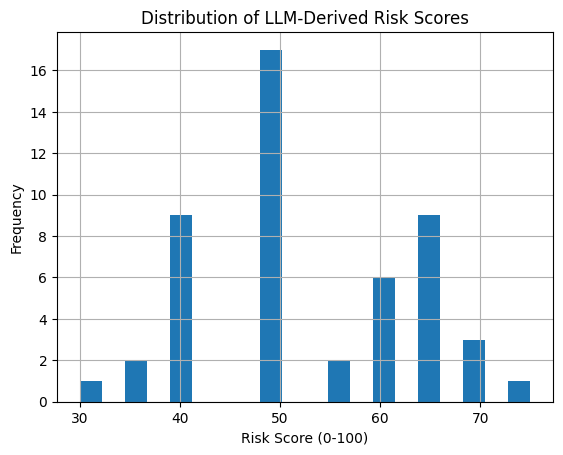

In [ ]:
# LLM Risk Score Distribution
# Visualize how the LLM assigns risk across loans

plt.figure()
enriched_df["llm_risk_score"].hist(bins=20)
plt.title("Distribution of LLM-Derived Risk Scores")
plt.xlabel("Risk Score (0-100)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Format Results

# Create Default Label
# Normalize MIS_Status by removing all spaces and uppercasing values

enriched_df["Default"] = (
    enriched_df["MIS_Status"]
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.strip()
    .str.upper()
    .map({
        "CHGOFF": 1,
        "PIF": 0
    })
)

print(enriched_df["Default"].value_counts(dropna=False))

Default
0    47
1     3
Name: count, dtype: int64


In [ ]:
# LLM Risk Score vs Actual Default
print(enriched_df.groupby("Default")["llm_risk_score"].mean())

Default
0    52.659574
1    58.333333
Name: llm_risk_score, dtype: float64


In [ ]:
# Tercile Risk Buckets
enriched_df["risk_bucket"] = pd.qcut(
    enriched_df["llm_risk_score"],
    q=3,
    labels=["Low", "Moderate", "High"],
    duplicates="drop"
)

print(enriched_df["risk_bucket"].value_counts())
print(enriched_df.groupby("risk_bucket")["Default"].mean())

risk_bucket
Low         29
High        13
Moderate     8
Name: count, dtype: int64
risk_bucket
Low         0.000
Moderate    0.375
High        0.000
Name: Default, dtype: float64


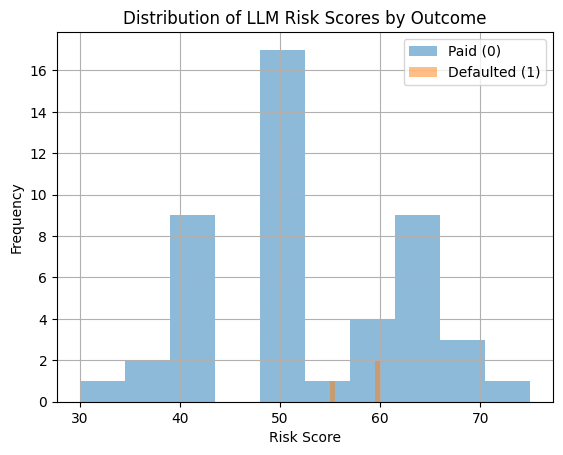

In [ ]:
# Histogram: Risk Score by Outcome

plt.figure()

enriched_df[enriched_df["Default"] == 0]["llm_risk_score"].hist(alpha=0.5, label="Paid (0)")
enriched_df[enriched_df["Default"] == 1]["llm_risk_score"].hist(alpha=0.5, label="Defaulted (1)")

plt.title("Distribution of LLM Risk Scores by Outcome")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

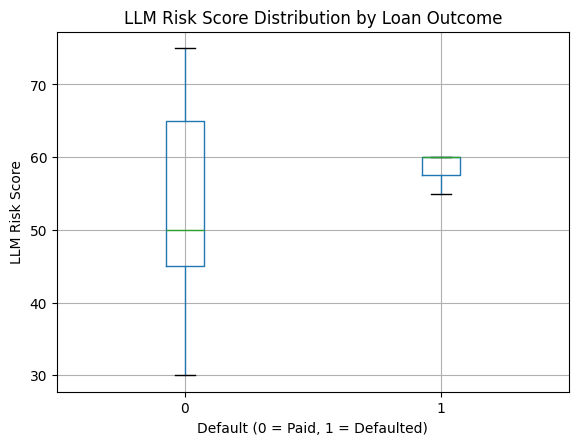

In [77]:
# Boxplot: LLM Risk Score by Default

plt.figure()
enriched_df.boxplot(column="llm_risk_score", by="Default")

plt.title("LLM Risk Score Distribution by Loan Outcome")
plt.suptitle("")  # remove automatic pandas title
plt.xlabel("Default (0 = Paid, 1 = Defaulted)")
plt.ylabel("LLM Risk Score")
plt.savefig('images/boxplot.png')

plt.show()